# Семинар 1: Masked Language Modeling — Архитектура и Обучение

Глава 11: Masked Language Models — Jurafsky & Martin, 2024

---

## Теоретический блок

### 1. Зачем нужны двунаправленные энкодеры?

Каузальные (авторегрессионные) языковые модели — GPT и его потомки — строят представление токена, видя **только левый контекст**:

$$P(x_t \mid x_1, x_2, \ldots, x_{t-1})$$

Для задач понимания (классификация, разметка) это ограничение существенно: правый контекст часто несёт не менее важную информацию. Рассмотрим пример: «Я взял удочку и пошёл на **берег**» — слово «берег», стоящее правее, однозначно сигнализирует о речном, а не финансовом значении слова «банк», если бы оно встречалось в этом предложении.

**Архитектурное решение.** В механизме self-attention нужно убрать маску верхнего треугольника:

$$\text{head} = \text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)\mathbf{V}$$

Теперь при вычислении представления токена $i$ внимание может смотреть на все позиции $1, \ldots, n$, включая те, что стоят после $i$. Эта незначительная с виду правка кардинально меняет характер модели: она перестаёт быть *генеративной* и становится *энкодерной* — её задача не генерировать текст, а строить богатые контекстные представления.

### 2. Masked Language Modeling (MLM)

Убрав причинную маску, мы не можем обучать модель как «угадай следующий токен» — ответ тривиально виден из правого контекста. Нужна новая обучающая задача.

Решение — **задача заполнения пропуска (cloze task)**: часть токенов скрывается, и модель должна их восстановить. Конкретно в BERT:

1. Случайно выбрать **15% токенов** последовательности.
2. Для каждого выбранного токена применить одно из трёх действий:
   - С вероятностью **80%**: заменить на специальный токен `[MASK]`
   - С вероятностью **10%**: заменить на случайный токен из словаря
   - С вероятностью **10%**: оставить без изменений
3. Модель должна восстановить исходный токен по контексту.

**Почему не только `[MASK]`?** Токен `[MASK]` никогда не встречается при применении (fine-tuning или инференс). Если обучать только на масках, модель «привыкает» предсказывать лишь тогда, когда видит `[MASK]`, и плохо работает при его отсутствии. Варианты «случайный токен» и «без изменений» вынуждают модель постоянно проверять каждый токен, а не ждать явного сигнала.

**Функция потерь.** Потери считаются только по выбранным позициям $M$:

$$\mathcal{L}_{\text{MLM}} = -\frac{1}{|M|} \sum_{i \in M} \log P(x_i \mid \mathbf{h}^L_i)$$

где $\mathbf{h}^L_i$ — выходной вектор последнего слоя трансформера для позиции $i$. Вероятность токена вычисляется через unembedding-слой:

$$\mathbf{u}_i = \mathbf{h}^L_i \mathbf{E}^\top, \quad \mathbf{y}_i = \text{softmax}(\mathbf{u}_i)$$

Обратите внимание: остальные $85\%$ токенов участвуют в self-attention (их векторы формируют контекст), но не вносят вклад в loss. Это означает, что BERT неэффективен по числу обучающих сигналов — только $15\%$ токенов реально обновляют веса на каждом шаге.

### 3. Next Sentence Prediction (NSP)

Помимо MLM, оригинальный BERT обучали второй задаче: предсказанию того, является ли второе предложение естественным продолжением первого.

Формат входа:
```
[CLS] Первое предложение [SEP] Второе предложение [SEP]
```

Вектор токена `[CLS]` подаётся в бинарный классификатор. $50\%$ пар — реально смежные, $50\%$ — случайно составленные. Суммарная потеря при предобучении: $\mathcal{L} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{NSP}}$.

Позднее выяснилось, что NSP не улучшает большинство downstream-задач — RoBERTa (Liu et al., 2019) отказалась от него и показала лучшие результаты.

### 4. Архитектура BERT

| Параметр | BERT-base | XLM-RoBERTa |
|----------|-----------|-------------|
| Словарь | 30 000 (WordPiece) | 250 000 (SentencePiece) |
| Контекст N | 512 токенов | 512 токенов |
| Размерность d | 768 | 1024 |
| Слоёв L | 12 | 24 |
| Голов внимания A | 12 | 16 |
| Параметров | ~110M | ~550M |

Для сравнения: Llama 3 имеет 405B параметров — в ~3600 раз больше BERT-base. Masked language models исторически значительно меньше каузальных LLM.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

def softmax(x, axis=-1):
    """Численно стабильный softmax: вычитаем максимум перед exp, чтобы избежать переполнения."""
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def one_hot(y, n):
    oh = np.zeros((len(y), n))
    oh[np.arange(len(y)), y] = 1
    return oh

print("Библиотеки загружены.")

Библиотеки загружены.


---

## Задача 1 (Простая): Причинная vs двунаправленная маска внимания

### Постановка

Нам дана последовательность из 5 токенов. Матрица скалярных произведений $\mathbf{Q}\mathbf{K}^\top$ уже вычислена. Нужно:

1. Применить **причинную маску**: заменить верхний треугольник матрицы (будущие токены) на $-\infty$ и применить softmax.
2. Применить **двунаправленное внимание**: softmax без каких-либо масок.
3. Визуально сравнить получившиеся матрицы весов внимания.

### Пояснение

В причинной модели каждый токен может "видеть" только себя и токены слева. Если мы обозначим позиции как $1, 2, 3, 4, 5$, то:
- токен 1 видит только токен 1;
- токен 3 видит токены 1, 2, 3;
- токен 5 видит все пять.

Это достигается заменой элементов $QK^\top[i,j]$ при $j > i$ на $-\infty$: после softmax они превратятся в нули.

В двунаправленной модели каждый токен видит **всех сразу** — матрица заполнена ненулевыми весами. Именно это обеспечивает богатый контекст: слово «банк» в позиции 2 сразу учитывает слово «река» в позиции 5, не дожидаясь авторегрессивного прохода.

### Что нужно заметить

В причинной матрице левый нижний треугольник заполнен, правый верхний — нулевой. В двунаправленной — вся матрица содержит ненулевые веса, и каждая строка суммируется в 1 (свойство softmax). Ни одна строка не "обрезана" заранее.

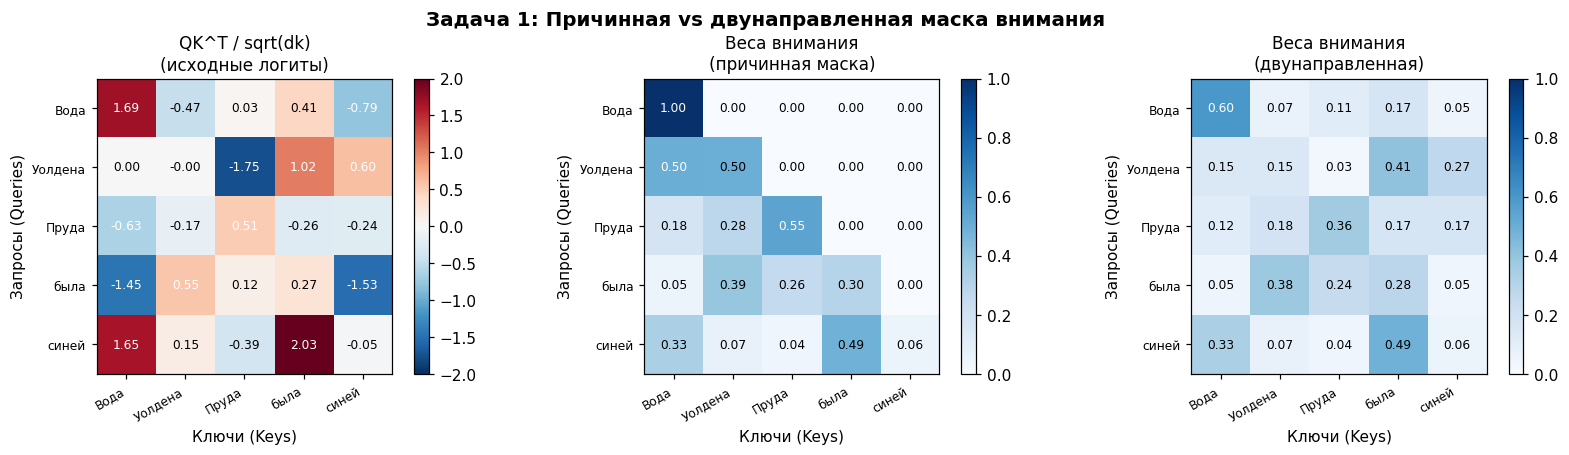

Сколько позиций видит каждый токен (ненулевые веса):
  Вода      : причинная = 1/5,  двунаправленная = 5/5
  Уолдена   : причинная = 2/5,  двунаправленная = 5/5
  Пруда     : причинная = 3/5,  двунаправленная = 5/5
  была      : причинная = 4/5,  двунаправленная = 5/5
  синей     : причинная = 5/5,  двунаправленная = 5/5

Пояснение к результатам:
Каждая строка матрицы внимания соответствует одному токену (запросу).
В причинной модели строка 'Вода' содержит ненулевой вес только в 1 ячейке:
токен видит лишь себя. В двунаправленной — все 5 ячеек ненулевые.
Строка всегда суммируется в 1 (свойство softmax), но распределяется по разным позициям.


In [ ]:
# Зададим матрицу QK^T для последовательности из 5 токенов.
# В реальном трансформере она вычисляется как произведение Q @ K.T,
# здесь мы сразу задаём её как случайную матрицу нужного масштаба.
dk = 64
np.random.seed(7)
QKT = np.random.randn(5, 5) * np.sqrt(dk)
QKT_scaled = QKT / np.sqrt(dk)   # масштабирование на sqrt(d_k), как в формуле

tokens = ["Вода", "Уолдена", "Пруда", "была", "синей"]

# --- Причинная маска ---
# np.triu с k=1 создаёт булеву матрицу True там, где j > i (верхний треугольник).
# Заменяем эти позиции на -1e9 (приближение -inf), чтобы softmax обнулил их.
causal_mask = np.triu(np.ones((5, 5)), k=1).astype(bool)
QKT_causal = QKT_scaled.copy()
QKT_causal[causal_mask] = -1e9
attn_causal = softmax(QKT_causal)

# --- Двунаправленное внимание ---
# Никакой маски — softmax применяется ко всей строке целиком.
attn_bidir = softmax(QKT_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Задача 1: Причинная vs двунаправленная маска внимания",
             fontsize=13, fontweight='bold')

for ax, data, title, cmap, vmin, vmax in [
    (axes[0], QKT_scaled, "QK^T / sqrt(dk)\n(исходные логиты)", 'RdBu_r', -2, 2),
    (axes[1], attn_causal, "Веса внимания\n(причинная маска)", 'Blues', 0, 1),
    (axes[2], attn_bidir,  "Веса внимания\n(двунаправленная)", 'Blues', 0, 1),
]:
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(tokens, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel("Ключи (Keys)")
    ax.set_ylabel("Запросы (Queries)")
    for i in range(5):
        for j in range(5):
            val = data[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=8, color=color)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Количественное сравнение: в причинной модели первые токены "ослеплены"
print("Сколько позиций видит каждый токен (ненулевые веса):")
for i, tok in enumerate(tokens):
    n_causal = (attn_causal[i] > 1e-6).sum()
    n_bidir  = (attn_bidir[i] > 1e-6).sum()
    print(f"  {tok:<10}: причинная = {n_causal}/5,  двунаправленная = {n_bidir}/5")

print("\nПояснение к результатам:")
print("Каждая строка матрицы внимания соответствует одному токену (запросу).")
print("В причинной модели строка 'Вода' содержит ненулевой вес только в 1 ячейке:")
print("токен видит лишь себя. В двунаправленной — все 5 ячеек ненулевые.")
print("Строка всегда суммируется в 1 (свойство softmax), но распределяется по разным позициям.")

---

## Задача 2 (Простая): Процедура маскирования токенов — правило 80/10/10

### Постановка

Дано предложение из 20 токенов. Нужно воспроизвести полную процедуру MLM-маскирования:

1. Случайно выбрать $15\%$ токенов.
2. Для каждого применить правило: `[MASK]` с вероятностью 80%, случайный токен — 10%, без изменений — 10%.
3. Сравнить исходную и испорченную последовательности.

### Пояснение

Зачем нужны три варианта, а не только `[MASK]`? Разберём каждый случай подробно.

**80% — замена на `[MASK]`.** Это основной сигнал: модель знает, что на этом месте что-то скрыто, и должна восстановить исходное слово по окружающему контексту. Именно здесь происходит основное обучение «понимать контекст».

**10% — замена на случайный токен.** Без этого варианта модель могла бы игнорировать все токены, кроме `[MASK]`, — ведь только они требуют предсказания. Случайная замена создаёт «шумовой» сигнал: модель вынуждена проверять каждый токен, даже внешне нормальный, и распознавать несоответствие контексту. Это делает представления более робастными.

**10% — без изменений.** Это важно для согласования предобучения и применения модели. При fine-tuning или инференсе `[MASK]` не используется вообще. Если бы все $15\%$ выбранных токенов заменялись, модель никогда не видела бы настоящих токенов на «проверяемых» позициях. Вариант «без изменений» учит её корректно обрабатывать реальные токены даже при вычислении loss.

### Что нужно заметить

Несмотря на три варианта действий, cross-entropy loss считается **одинаково** для всех выбранных позиций — всегда относительно исходного правильного токена, независимо от того, что именно подалось на вход.

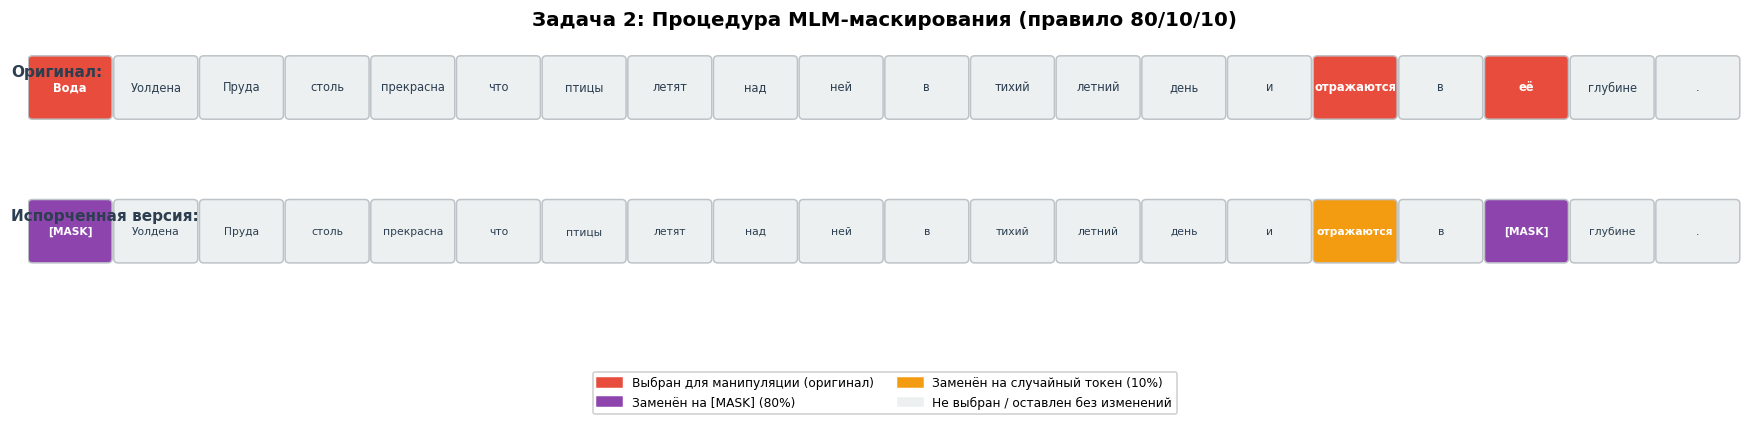

Выбранные позиции и применённые действия:
 Позиция    Оригинальный токен  Действие
--------------------------------------------------------
       0                  Вода  [MASK]
      15            отражаются  без изменений
      17                    её  [MASK]

Выбрано 3 из 20 токенов (15%)
Loss будет считаться именно по этим позициям — модель угадывает исходное слово,
независимо от того, что реально подалось на вход ([MASK], случайное или то же слово).


In [ ]:
sentence = [
    "Вода", "Уолдена", "Пруда", "столь", "прекрасна",
    "что", "птицы", "летят", "над", "ней",
    "в", "тихий", "летний", "день", "и",
    "отражаются", "в", "её", "глубине", "."
]

# Расширенный словарь для случайных замен
vocab = sentence + ["рыба", "дерево", "ветер", "облако", "солнце",
                    "гора", "пруд", "лес", "небо", "трава"]

np.random.seed(42)
n_tokens = len(sentence)
# 15% от 20 = 3 токена; max(1, ...) гарантирует хотя бы один
n_mask = max(1, int(0.15 * n_tokens))
mask_positions = sorted(np.random.choice(n_tokens, n_mask, replace=False))

corrupted = sentence.copy()
actions = []   # для вывода таблицы результатов

for pos in mask_positions:
    r = np.random.random()
    if r < 0.80:
        action = "[MASK]"
        corrupted[pos] = "[MASK]"
    elif r < 0.90:
        rand_tok = np.random.choice(vocab)
        action = f"случайный: '{rand_tok}'"
        corrupted[pos] = rand_tok
    else:
        action = "без изменений"
    actions.append((pos, sentence[pos], action))

# Визуализация: две строки токенов — оригинал и испорченная версия
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, n_tokens)
ax.set_ylim(0, 3.8)
ax.axis('off')
ax.set_title("Задача 2: Процедура MLM-маскирования (правило 80/10/10)",
             fontsize=13, fontweight='bold')

ax.text(-0.2, 3.3, "Оригинал:", fontsize=10, fontweight='bold', color='#2c3e50')
ax.text(-0.2, 1.6, "Испорченная версия:", fontsize=10, fontweight='bold', color='#2c3e50')

for i, tok in enumerate(sentence):
    fc = '#e74c3c' if i in mask_positions else '#ecf0f1'
    tc = 'white' if i in mask_positions else '#2c3e50'
    rect = mpatches.FancyBboxPatch((i+0.05, 2.85), 0.88, 0.65,
                                    boxstyle="round,pad=0.05",
                                    facecolor=fc, edgecolor='#bdc3c7', linewidth=1)
    ax.add_patch(rect)
    ax.text(i+0.49, 3.17, tok, ha='center', va='center', fontsize=7.5,
            color=tc, fontweight='bold' if i in mask_positions else 'normal')

for i, tok in enumerate(corrupted):
    if i in mask_positions:
        fc = '#8e44ad' if tok == '[MASK]' else '#f39c12'
    else:
        fc = '#ecf0f1'
    tc = 'white' if fc not in ['#ecf0f1'] else '#2c3e50'
    rect = mpatches.FancyBboxPatch((i+0.05, 1.15), 0.88, 0.65,
                                    boxstyle="round,pad=0.05",
                                    facecolor=fc, edgecolor='#bdc3c7', linewidth=1)
    ax.add_patch(rect)
    ax.text(i+0.49, 1.47, tok, ha='center', va='center', fontsize=7,
            color=tc, fontweight='bold' if i in mask_positions else 'normal')

patches = [
    mpatches.Patch(color='#e74c3c', label='Выбран для манипуляции (оригинал)'),
    mpatches.Patch(color='#8e44ad', label='Заменён на [MASK] (80%)'),
    mpatches.Patch(color='#f39c12', label='Заменён на случайный токен (10%)'),
    mpatches.Patch(color='#ecf0f1', label='Не выбран / оставлен без изменений'),
]
ax.legend(handles=patches, loc='lower center', ncol=2, fontsize=8,
          bbox_to_anchor=(0.5, -0.2), framealpha=0.95)
plt.tight_layout()
plt.show()

print("Выбранные позиции и применённые действия:")
print(f"{'Позиция':>8}  {'Оригинальный токен':>20}  {'Действие'}")
print("-" * 56)
for pos, orig, act in actions:
    print(f"{pos:>8}  {orig:>20}  {act}")

print(f"\nВыбрано {n_mask} из {n_tokens} токенов ({n_mask/n_tokens*100:.0f}%)")
print("Loss будет считаться именно по этим позициям — модель угадывает исходное слово,")
print("независимо от того, что реально подалось на вход ([MASK], случайное или то же слово).")

---

## Задача 3 (Простая): Вычисление cross-entropy loss для MLM

### Постановка

Модель предсказывает замаскированный токен «прекрасна». Дан вектор логитов размером 10 (мини-словарь). Нужно:

1. Вычислить вероятности через softmax.
2. Найти cross-entropy loss для правильного токена.
3. Сравнить три сценария: хорошее предсказание, плохое и равномерное.

### Пояснение

Вспомним цепочку вычислений. На входе — выходной вектор трансформера $\mathbf{h}^L_i$ для замаскированной позиции. Его умножают на транспонированную матрицу эмбеддингов $\mathbf{E}^\top$:

$$\mathbf{u}_i = \mathbf{h}^L_i \mathbf{E}^\top$$

Получается вектор **логитов** $\mathbf{u}_i \in \mathbb{R}^V$, по одному числу на каждый токен в словаре. Затем softmax переводит логиты в вероятности:

$$y_k = \frac{\exp(u_k)}{\sum_j \exp(u_j)}$$

Наконец, loss — это **отрицательный логарифм вероятности правильного ответа**:

$$\mathcal{L} = -\log y_{\text{correct}}$$

Этот вид потерь называется cross-entropy. Её свойства:
- Если $y_{\text{correct}} \approx 1$ (модель уверена и права) — $\mathcal{L} \approx 0$.
- Если $y_{\text{correct}} \approx 1/V$ (равномерное распределение, словарь из $V$ токенов) — $\mathcal{L} = \log V$.
- Если $y_{\text{correct}} \approx 0$ (модель уверена, но ошиблась) — $\mathcal{L} \to \infty$.

### Что нужно заметить

Сравнивая три сценария, обратите внимание на то, насколько чувствителен loss к вероятности правильного ответа. Разница в $p = 0.85$ и $p = 0.01$ даёт потери $0.16$ против $4.6$ — более чем в 28 раз. Именно эта чувствительность делает cross-entropy хорошей функцией потерь для классификации.

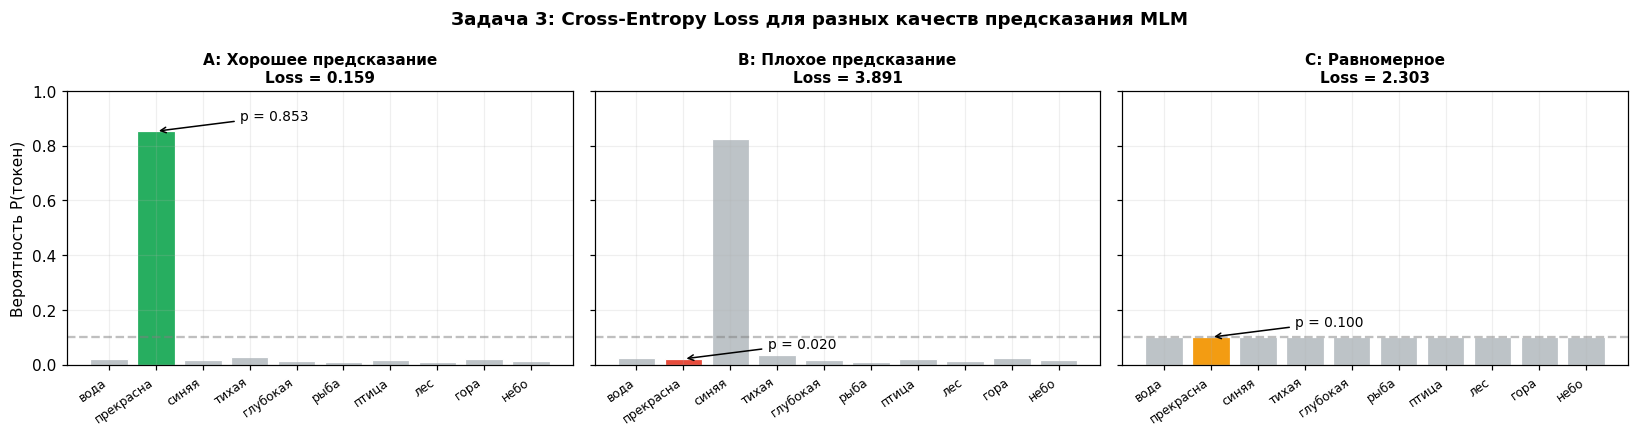

Сводная таблица результатов:
Сценарий                 P(верный токен)    CE Loss
----------------------------------------------------
A (хорошее)                       0.8530     0.1590
B (плохое)                        0.0204     3.8911
C (равномерное)                   0.1000     2.3026

Теоретический loss при равномерном распределении: log(V) = log(10) = 2.3026
Что совпадает с C: 2.3026

Смысл: модель в начале обучения предсказывает почти равномерно (loss ~ log V).
По мере обучения она концентрирует вероятность на правильных токенах, loss падает к 0.


In [ ]:
mini_vocab = ["вода", "прекрасна", "синяя", "тихая", "глубокая",
              "рыба", "птица", "лес", "гора", "небо"]
correct_idx = 1  # правильный ответ — «прекрасна»

# Три набора логитов: разное качество предсказания
logits_good = np.array([0.5, 4.2, 0.3, 0.8, 0.1, -0.5, 0.2, -0.3, 0.4, 0.1])
logits_bad  = np.array([0.5, 0.3, 4.0, 0.8, 0.1, -0.5, 0.2, -0.3, 0.4, 0.1])
logits_flat = np.zeros(10)  # равномерное: все логиты одинаковы

def compute_loss(logits, true_idx):
    probs = softmax(logits)
    loss  = -np.log(probs[true_idx] + 1e-12)
    return probs, loss

probs_good, loss_good = compute_loss(logits_good, correct_idx)
probs_bad,  loss_bad  = compute_loss(logits_bad,  correct_idx)
probs_flat, loss_flat = compute_loss(logits_flat, correct_idx)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Задача 3: Cross-Entropy Loss для разных качеств предсказания MLM",
             fontsize=12, fontweight='bold')

scenarios = [
    (probs_good, loss_good, "A: Хорошее предсказание",  '#27ae60'),
    (probs_bad,  loss_bad,  "B: Плохое предсказание",   '#e74c3c'),
    (probs_flat, loss_flat, "C: Равномерное",            '#f39c12'),
]

for ax, (probs, loss, title, color) in zip(axes, scenarios):
    bar_colors = [color if i == correct_idx else '#bdc3c7' for i in range(10)]
    ax.bar(range(10), probs, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(10))
    ax.set_xticklabels(mini_vocab, rotation=35, ha='right', fontsize=8)
    ax.set_title(f"{title}\nLoss = {loss:.3f}", fontsize=10, fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel("Вероятность P(токен)")
    ax.axhline(y=0.1, color='grey', linestyle='--', alpha=0.5,
               label='Равномерное (0.1)')
    ax.annotate(f"p = {probs[correct_idx]:.3f}",
                xy=(correct_idx, probs[correct_idx]),
                xytext=(correct_idx + 1.8, probs[correct_idx] + 0.04),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("Сводная таблица результатов:")
print(f"{'Сценарий':<22}  {'P(верный токен)':>16}  {'CE Loss':>9}")
print("-" * 52)
for label, prob, loss in [
    ("A (хорошее)",    probs_good[correct_idx], loss_good),
    ("B (плохое)",     probs_bad[correct_idx],  loss_bad),
    ("C (равномерное)",probs_flat[correct_idx], loss_flat),
]:
    print(f"{label:<22}  {prob:>16.4f}  {loss:>9.4f}")

print(f"\nТеоретический loss при равномерном распределении: log(V) = log(10) = {np.log(10):.4f}")
print(f"Что совпадает с C: {loss_flat:.4f}")
print("\nСмысл: модель в начале обучения предсказывает почти равномерно (loss ~ log V).")
print("По мере обучения она концентрирует вероятность на правильных токенах, loss падает к 0.")

---

## Задача 4 (Средняя): Симуляция обучения MLM — динамика потерь

### Постановка

Смоделировать процесс обучения MLM за 120 шагов на батчах из 8 предложений по 20 токенов:

1. На каждом шаге применять маскирование 15% токенов.
2. Имитировать «улучшающуюся» модель: со временем правильный токен получает всё больший логит.
3. Вычислять MLM-loss за шаг, строить кривую обучения.
4. Сравнить loss по замаскированным позициям и гипотетический loss по всем позициям.

### Пояснение

Ключевое понятие здесь — **эффективность обучения**. BERT обновляет веса только по $15\%$ токенов за шаг. Оставшиеся $85\%$ участвуют в вычислении контекстных представлений (через self-attention), но не вносят вклад в loss и не создают градиентов.

Это принципиальное отличие от каузальных LM (GPT), где каждый токен (кроме первого) является обучающим сигналом — то есть $\approx 100\%$ токенов используются.

Почему BERT тем не менее работает? Потому что каждый из $15\%$ обучающих токенов опирается на **двунаправленный** контекст — представление из всего предложения сразу. Это богаче, чем предсказание следующего слова только по левому контексту.

### Что нужно заметить

На графике кривой обучения loss начинается около $\log(V)$ (случайные предсказания) и постепенно снижается. На правом графике видно расхождение между «реальным MLM loss» и гипотетическим «полным loss» — именно этот разрыв характеризует неэффективность MLM. Модель ELECTRA устраняет его, обучая дискриминатор на всех токенах.

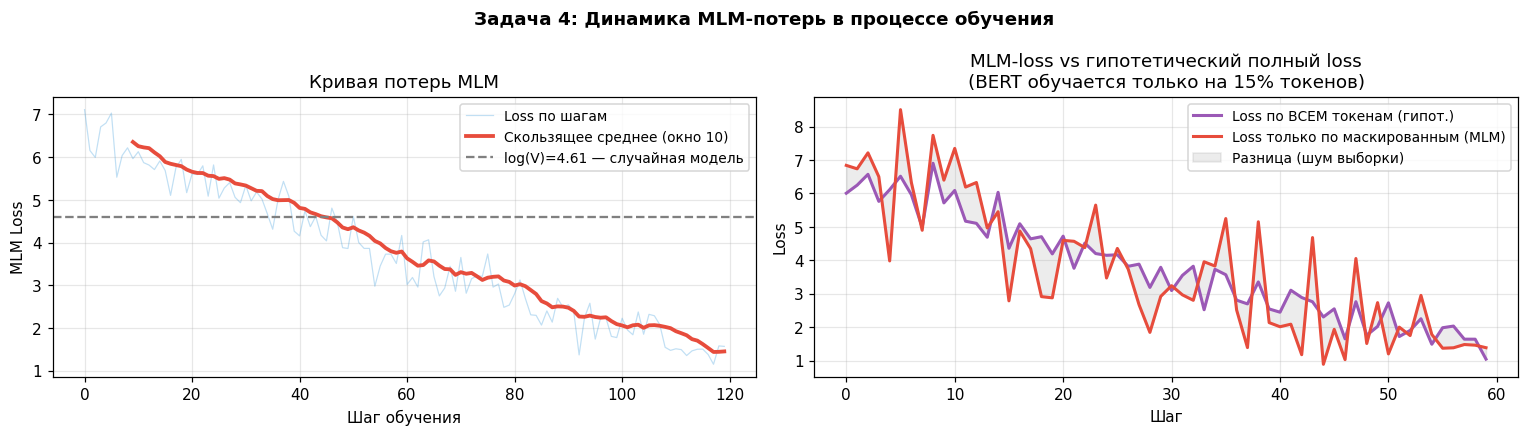

Loss на старте: 7.111
Loss в конце:   1.568
Снижение:       77.9%

Пояснение к правому графику:
Если бы loss считался по всем 20 токенам (фиолетовая линия),
мы получали бы в 1/0.15 = 6.7 раз больше обучающих сигналов за шаг.
Именно это делает ELECTRA: обучает бинарный классификатор на ВСЕХ токенах.


In [ ]:
VOCAB_SIZE = 100
SEQ_LEN = 20
BATCH = 8
STEPS = 120
np.random.seed(0)

def simulate_mlm_step(step, total_steps):
    """
    Симуляция одного шага MLM:
    - Генерируем батч токенов.
    - Маскируем 15%.
    - Имитируем предсказания: качество нарастает с числом шагов
      (это моделирует эффект обучения весов).
    - Считаем средний loss только по замаскированным позициям.
    """
    quality = step / total_steps   # от 0 до 1: чем больше, тем лучше предсказания
    total_loss = 0.0
    total_masked = 0

    for _ in range(BATCH):
        sent = np.random.randint(0, VOCAB_SIZE, SEQ_LEN)
        n_mask = max(1, int(0.15 * SEQ_LEN))
        mask_pos = np.random.choice(SEQ_LEN, n_mask, replace=False)

        for pos in mask_pos:
            true_tok = sent[pos]
            logits = np.random.randn(VOCAB_SIZE) * 2.0
            # Чем позже шаг, тем сильнее "сигнал" у правильного токена
            logits[true_tok] += quality * 6.0
            probs = softmax(logits)
            total_loss += -np.log(probs[true_tok] + 1e-12)
            total_masked += 1

    return total_loss / total_masked

losses = [simulate_mlm_step(s, STEPS) for s in range(STEPS)]

# Сглаживание скользящим средним
window = 10
losses_smooth = np.convolve(losses, np.ones(window)/window, mode='valid')

# Гипотетический loss по всем токенам (для сравнения)
np.random.seed(1)
losses_all_tokens = []
losses_only_masked = []
for s in range(60):
    q = s / 60
    sent = np.random.randint(0, VOCAB_SIZE, SEQ_LEN)
    logits_all = np.random.randn(SEQ_LEN, VOCAB_SIZE) * 2
    for i in range(SEQ_LEN):
        logits_all[i, sent[i]] += q * 6
    probs_all = softmax(logits_all)
    full_loss = np.mean([-np.log(probs_all[i, sent[i]] + 1e-12) for i in range(SEQ_LEN)])
    losses_all_tokens.append(full_loss)
    n_m = int(0.15 * SEQ_LEN)
    m_pos = np.random.choice(SEQ_LEN, n_m, replace=False)
    mlm_l = np.mean([-np.log(probs_all[i, sent[i]] + 1e-12) for i in m_pos])
    losses_only_masked.append(mlm_l)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Задача 4: Динамика MLM-потерь в процессе обучения",
             fontsize=12, fontweight='bold')

axes[0].plot(losses, alpha=0.3, color='#3498db', linewidth=0.8, label='Loss по шагам')
axes[0].plot(range(window-1, STEPS), losses_smooth, color='#e74c3c',
             linewidth=2.5, label=f'Скользящее среднее (окно {window})')
axes[0].axhline(y=np.log(VOCAB_SIZE), color='grey', linestyle='--',
                label=f'log(V)={np.log(VOCAB_SIZE):.2f} — случайная модель')
axes[0].set_xlabel("Шаг обучения")
axes[0].set_ylabel("MLM Loss")
axes[0].set_title("Кривая потерь MLM")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(losses_all_tokens,   color='#9b59b6', linewidth=2, label='Loss по ВСЕМ токенам (гипот.)')
axes[1].plot(losses_only_masked,  color='#e74c3c', linewidth=2, label='Loss только по маскированным (MLM)')
axes[1].fill_between(range(60), losses_all_tokens, losses_only_masked,
                     alpha=0.15, color='grey', label='Разница (шум выборки)')
axes[1].set_xlabel("Шаг")
axes[1].set_ylabel("Loss")
axes[1].set_title("MLM-loss vs гипотетический полный loss\n(BERT обучается только на 15% токенов)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Loss на старте: {losses[0]:.3f}")
print(f"Loss в конце:   {losses[-1]:.3f}")
print(f"Снижение:       {(1 - losses[-1]/losses[0])*100:.1f}%")
print("\nПояснение к правому графику:")
print("Если бы loss считался по всем 20 токенам (фиолетовая линия),")
print("мы получали бы в 1/0.15 = 6.7 раз больше обучающих сигналов за шаг.")
print("Именно это делает ELECTRA: обучает бинарный классификатор на ВСЕХ токенах.")

---

## Задача 5 (Средняя): NSP — формирование входа и специальные токены

### Постановка

Реализовать полную схему подготовки входа для NSP-обучения:

1. Сформировать 4 пары предложений: 2 смежные (метка IsNext) и 2 случайные (NotNext).
2. Добавить специальные токены `[CLS]` и `[SEP]`, а также сегментные метки S0/S1.
3. Объяснить, почему RoBERTa отказалась от этой задачи.

### Пояснение

Чтобы модель научилась понимать отношения между предложениями, BERT использует особый формат входа:

- `[CLS]` — первый токен любого входа. Его выходной вектор $\mathbf{h}^L_{\text{CLS}}$ агрегирует информацию о всём тексте и используется как вход в классификатор NSP.
- `[SEP]` — разделитель между двумя предложениями и маркер конца.
- **Сегментные эмбеддинги**: к каждому токену добавляется вектор $\mathbf{s}_0$ или $\mathbf{s}_1$, указывающий, к какому предложению он принадлежит. Это позволяет модели различать два предложения в одном входе.

Входной вектор каждого токена формируется как сумма трёх компонент:
$$\mathbf{x}_i = \mathbf{e}^{\text{token}}_i + \mathbf{e}^{\text{pos}}_i + \mathbf{e}^{\text{seg}}_i$$

**Почему RoBERTa отказалась от NSP?** Исследования показали, что NSP слишком прост: пары из разных документов легко распознаются по разрыву темы, что достигается поверхностным анализом лексики, а не пониманием связности. Кроме того, попытка объединить два разных документа в одну обучающую пару разрушает длинный контекст внутри документа, что вредит MLM.

### Что нужно заметить

Обратите внимание, что каждый токен первого предложения получает метку S0, а второго — S1. Специальные токены `[CLS]` и первый `[SEP]` также относятся к S0.

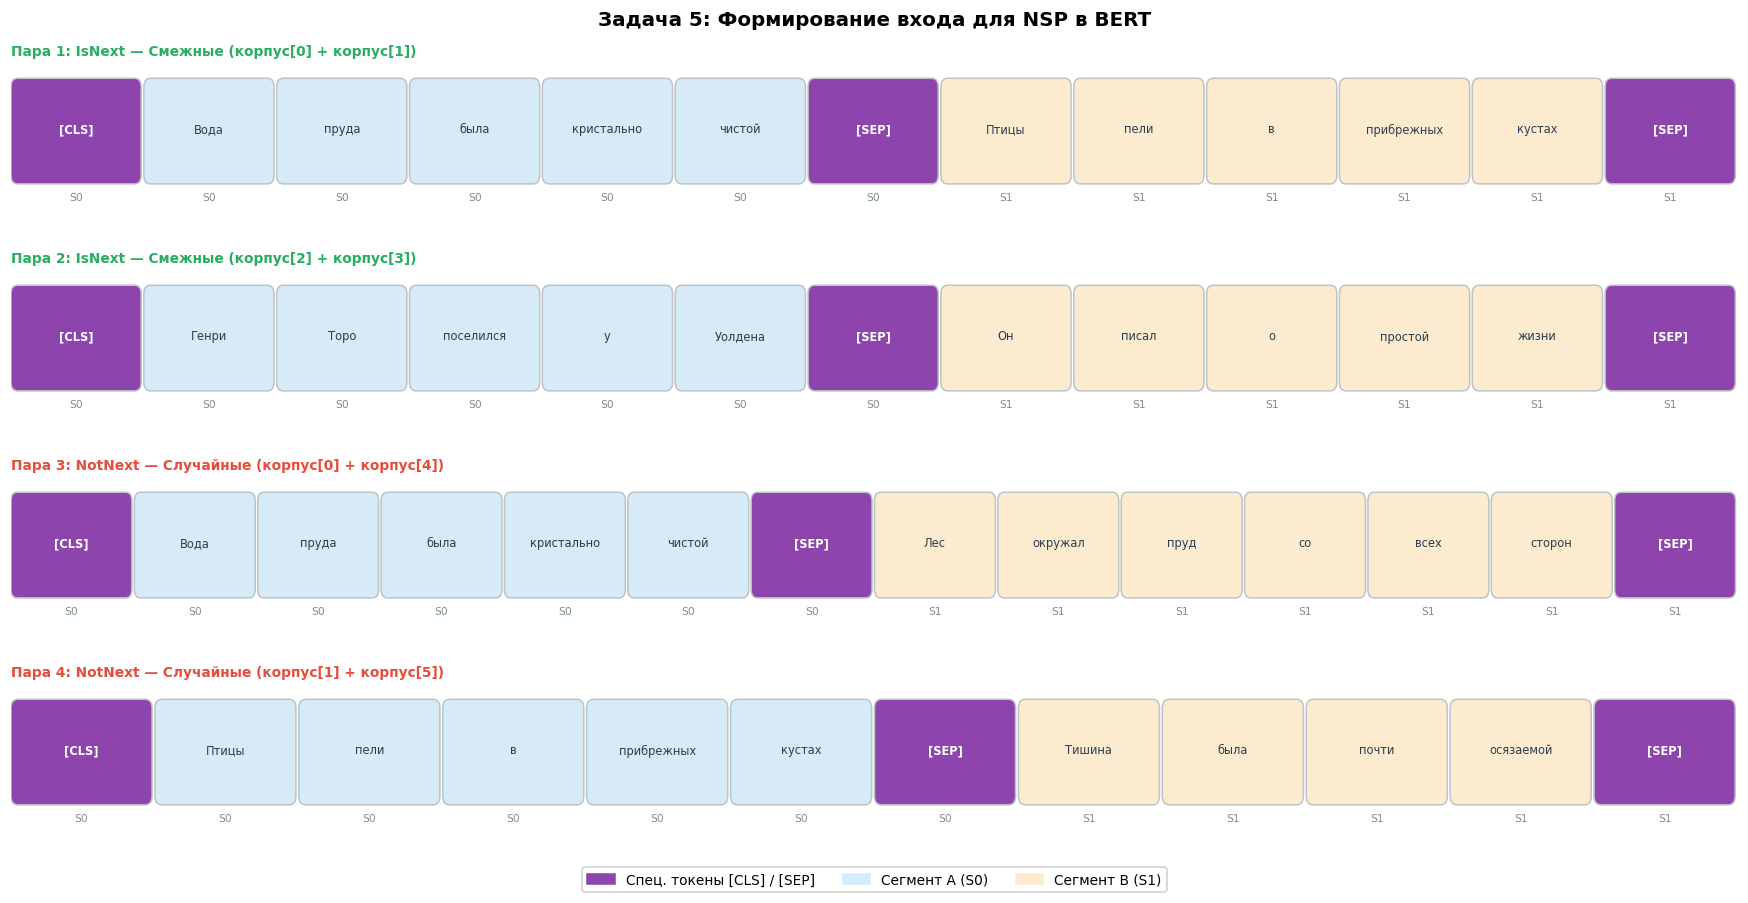

Длины входных последовательностей:
  Пара 1 (  IsNext):  13 токена — Смежные (корпус[0] + корпус[1])
  Пара 2 (  IsNext):  13 токена — Смежные (корпус[2] + корпус[3])
  Пара 3 ( NotNext):  14 токена — Случайные (корпус[0] + корпус[4])
  Пара 4 ( NotNext):  12 токена — Случайные (корпус[1] + корпус[5])

Структура входа:
  [CLS] <предложение A> [SEP] <предложение B> [SEP]
  Каждый токен = эмбеддинг_токена + позиционный_эмбеддинг + сегментный_эмбеддинг

Почему RoBERTa отказалась от NSP:
  1. Задача слишком проста — разные документы отличаются по теме лексически.
  2. Смешивание двух документов разрушает дальний контекст внутри каждого.
  3. Без NSP модель лучше учит MLM, что важнее для downstream-задач.


In [ ]:
corpus = [
    "Вода пруда была кристально чистой".split(),
    "Птицы пели в прибрежных кустах".split(),
    "Генри Торо поселился у Уолдена".split(),
    "Он писал о простой жизни".split(),
    "Лес окружал пруд со всех сторон".split(),
    "Тишина была почти осязаемой".split(),
]

def make_nsp_input(sent_a, sent_b):
    """Формирует список токенов и сегментных меток для пары предложений."""
    tokens  = ["[CLS]"] + sent_a + ["[SEP]"] + sent_b + ["[SEP]"]
    seg_ids = [0] * (len(sent_a) + 2) + [1] * (len(sent_b) + 1)
    return tokens, seg_ids

# Создаём 4 пары: 2 смежных, 2 случайных
pairs = [
    (make_nsp_input(corpus[0], corpus[1]), True,  "Смежные (корпус[0] + корпус[1])"),
    (make_nsp_input(corpus[2], corpus[3]), True,  "Смежные (корпус[2] + корпус[3])"),
    (make_nsp_input(corpus[0], corpus[4]), False, "Случайные (корпус[0] + корпус[4])"),
    (make_nsp_input(corpus[1], corpus[5]), False, "Случайные (корпус[1] + корпус[5])"),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 8))
fig.suptitle("Задача 5: Формирование входа для NSP в BERT",
             fontsize=13, fontweight='bold')

for ax_idx, ((tokens, seg_ids), is_next, description) in enumerate(pairs):
    ax = axes[ax_idx]
    ax.set_xlim(0, len(tokens))
    ax.set_ylim(0, 1)
    ax.axis('off')
    label_color = '#27ae60' if is_next else '#e74c3c'
    label_text = "IsNext" if is_next else "NotNext"
    ax.set_title(f"Пара {ax_idx+1}: {label_text} — {description}",
                 fontsize=9, color=label_color, loc='left', fontweight='bold')

    for i, (tok, seg) in enumerate(zip(tokens, seg_ids)):
        if tok in ["[CLS]", "[SEP]"]:
            fc, tc = '#8e44ad', 'white'
        else:
            fc = '#d6eaf8' if seg == 0 else '#fdebd0'
            tc = '#2c3e50'
        rect = mpatches.FancyBboxPatch((i+0.05, 0.35), 0.88, 0.52,
                                        boxstyle="round,pad=0.05",
                                        facecolor=fc, edgecolor='#bdc3c7')
        ax.add_patch(rect)
        ax.text(i+0.49, 0.62, tok, ha='center', va='center', fontsize=7.5,
                color=tc, fontweight='bold' if tok in ["[CLS]", "[SEP]"] else 'normal')
        ax.text(i+0.49, 0.22, f"S{seg}", ha='center', va='center',
                fontsize=7, color='#7f8c8d')

patches = [
    mpatches.Patch(color='#8e44ad', label='Спец. токены [CLS] / [SEP]'),
    mpatches.Patch(color='#d6eaf8', label='Сегмент A (S0)'),
    mpatches.Patch(color='#fdebd0', label='Сегмент B (S1)'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.03), framealpha=0.95)
plt.tight_layout()
plt.show()

print("Длины входных последовательностей:")
for i, ((tokens, _), is_next, desc) in enumerate(pairs):
    print(f"  Пара {i+1} ({('IsNext' if is_next else 'NotNext'):>8}): {len(tokens):>3} токена — {desc}")

print("\nСтруктура входа:")
print("  [CLS] <предложение A> [SEP] <предложение B> [SEP]")
print("  Каждый токен = эмбеддинг_токена + позиционный_эмбеддинг + сегментный_эмбеддинг")
print("\nПочему RoBERTa отказалась от NSP:")
print("  1. Задача слишком проста — разные документы отличаются по теме лексически.")
print("  2. Смешивание двух документов разрушает дальний контекст внутри каждого.")
print("  3. Без NSP модель лучше учит MLM, что важнее для downstream-задач.")

---

## Задача 6 (Средняя): Сравнение эффективности MLM и каузальных LM по числу обучающих сигналов

### Постановка

Для корпуса из 1000 предложений по 50 токенов сравнить две парадигмы обучения по числу полезных обучающих сигналов при разных размерах батча:

- **Каузальная LM**: каждый токен (кроме первого) — это один обучающий сигнал.
- **MLM**: только $15\%$ токенов дают обучающий сигнал.

### Пояснение

«Обучающий сигнал» — это один элемент суммы в функции потерь, то есть одно предсказание, по которому считается градиент и обновляются веса. Чем больше таких предсказаний за шаг, тем эффективнее используется вычислительный ресурс.

В каузальной LM для последовательности $x_1, \ldots, x_N$ каждый переход $x_{t-1} \to x_t$ является обучающим сигналом: модель предсказывает $x_t$ по $x_1, \ldots, x_{t-1}$. Это $N-1 \approx N$ сигналов на предложение.

В MLM за шаг мы маскируем $0.15N$ токенов, и только они создают градиенты. Остальные $0.85N$ токенов «вычислительно участвуют» (проходят через трансформер), но **не обновляют веса**.

На практике разрыв компенсируется тем, что BERT обучался ~40 эпох на ~3.3 млрд слов, а RoBERTa — на 300 млрд токенов. Большой объём данных нивелирует неэффективность $15\%$-маскирования.

### Что нужно заметить

Независимо от размера батча, MLM использует ровно $15\%$ от общего числа токенов. Число шагов при большем батче меньше (меньше итераций на эпоху), но общее число сигналов за эпоху остаётся примерно одинаковым — что видно на правом графике.

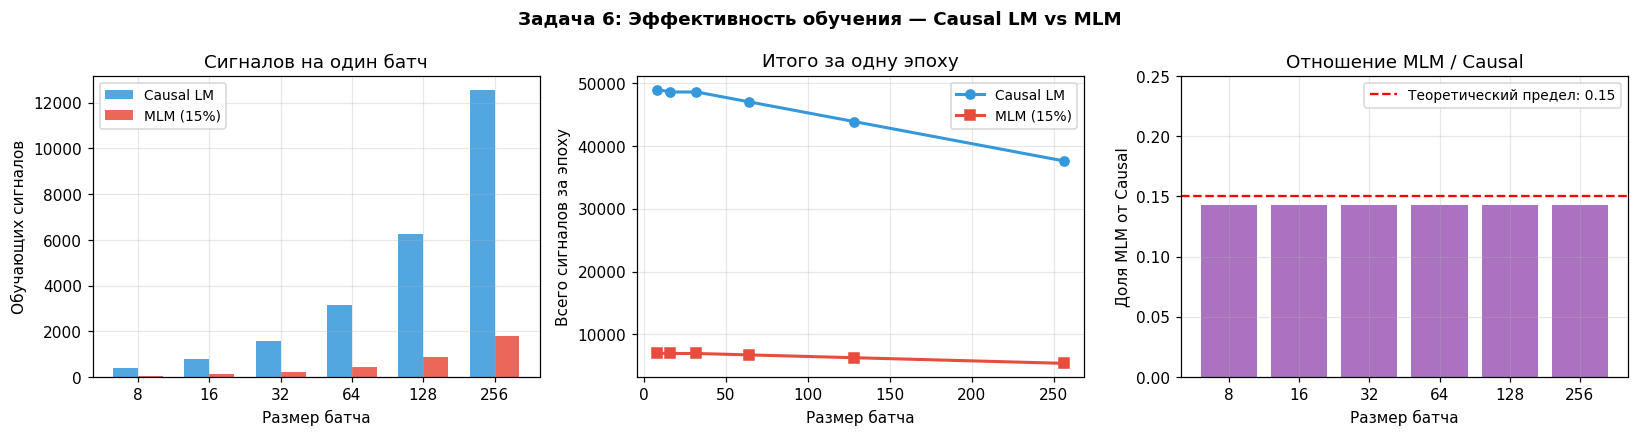

Сводная таблица:
  Батч    Шагов   Causal/батч    MLM/батч   MLM/Causal
------------------------------------------------------
     8      125           392          56        0.143
    16       62           784         112        0.143
    32       31          1568         224        0.143
    64       15          3136         448        0.143
   128        7          6272         896        0.143
   256        3         12544        1792        0.143

Вывод: MLM использует в ~6.5 раз меньше обучающих сигналов, чем Causal LM.
Компенсация: двунаправленный контекст делает каждый сигнал богаче информационно.


In [ ]:
CORPUS_SIZE = 1000
SEQ_LEN_EFF = 50
MLM_RATIO = 0.15
batch_sizes = [8, 16, 32, 64, 128, 256]

results = []
for bs in batch_sizes:
    n_batches = CORPUS_SIZE // bs

    # Каузальная LM: N-1 предсказаний на последовательность
    causal_per_batch = bs * (SEQ_LEN_EFF - 1)
    causal_total     = n_batches * causal_per_batch

    # MLM: 15% токенов
    mlm_per_batch = bs * int(SEQ_LEN_EFF * MLM_RATIO)
    mlm_total     = n_batches * mlm_per_batch

    results.append({
        'batch': bs, 'n_batches': n_batches,
        'causal_per_batch': causal_per_batch,
        'mlm_per_batch': mlm_per_batch,
        'causal_total': causal_total,
        'mlm_total': mlm_total,
    })

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Задача 6: Эффективность обучения — Causal LM vs MLM",
             fontsize=12, fontweight='bold')

x = np.arange(len(batch_sizes))
w = 0.35

causal_per = [r['causal_per_batch'] for r in results]
mlm_per    = [r['mlm_per_batch']    for r in results]
axes[0].bar(x - w/2, causal_per, w, label='Causal LM', color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, mlm_per,    w, label='MLM (15%)',  color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(b) for b in batch_sizes])
axes[0].set_xlabel("Размер батча")
axes[0].set_ylabel("Обучающих сигналов")
axes[0].set_title("Сигналов на один батч")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

causal_tot = [r['causal_total'] for r in results]
mlm_tot    = [r['mlm_total']    for r in results]
axes[1].plot(batch_sizes, causal_tot, 'o-', color='#3498db', linewidth=2, label='Causal LM')
axes[1].plot(batch_sizes, mlm_tot,    's-', color='#e74c3c', linewidth=2, label='MLM (15%)')
axes[1].set_xlabel("Размер батча")
axes[1].set_ylabel("Всего сигналов за эпоху")
axes[1].set_title("Итого за одну эпоху")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

ratios = [r['mlm_total'] / r['causal_total'] for r in results]
axes[2].bar(range(len(batch_sizes)), ratios, color='#9b59b6', alpha=0.85)
axes[2].axhline(y=MLM_RATIO, color='red', linestyle='--', linewidth=1.5,
                label=f'Теоретический предел: {MLM_RATIO}')
axes[2].set_xticks(range(len(batch_sizes)))
axes[2].set_xticklabels([str(b) for b in batch_sizes])
axes[2].set_xlabel("Размер батча")
axes[2].set_ylabel("Доля MLM от Causal")
axes[2].set_title("Отношение MLM / Causal")
axes[2].set_ylim(0, 0.25)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Сводная таблица:")
print(f"{'Батч':>6}  {'Шагов':>7}  {'Causal/батч':>12}  {'MLM/батч':>10}  {'MLM/Causal':>11}")
print("-" * 54)
for r in results:
    print(f"{r['batch']:>6}  {r['n_batches']:>7}  {r['causal_per_batch']:>12}  {r['mlm_per_batch']:>10}  "
          f"{r['mlm_per_batch']/r['causal_per_batch']:>11.3f}")
print("\nВывод: MLM использует в ~6.5 раз меньше обучающих сигналов, чем Causal LM.")
print("Компенсация: двунаправленный контекст делает каждый сигнал богаче информационно.")

---

## Задача 7 (Сложная): Полная схема MLM-предобучения — матричные вычисления

### Постановка

Реализовать упрощённый однослойный трансформерный энкодер с MLM-целью:

1. Сформировать входные эмбеддинги (токен + позиция).
2. Вычислить один слой двунаправленного self-attention.
3. Применить unembedding, softmax, посчитать cross-entropy loss.
4. Убедиться, что loss считается только по замаскированным позициям.

### Пояснение

Проследим полный путь данных через трансформерный энкодер.

**Шаг 1. Входные эмбеддинги.** Каждый токен $x_i$ заменяется строкой матрицы эмбеддингов $\mathbf{E}$: $\mathbf{e}_i = \mathbf{E}[x_i]$. К ней прибавляется позиционный эмбеддинг $\mathbf{p}_i$, кодирующий положение токена в последовательности. Сумма $\mathbf{X} = \mathbf{E}[\mathbf{x}] + \mathbf{P}$ — это вход трансформера.

**Шаг 2. Self-Attention.** Вычисляем проекции: $\mathbf{Q} = \mathbf{X}\mathbf{W}_Q$, $\mathbf{K} = \mathbf{X}\mathbf{W}_K$, $\mathbf{V} = \mathbf{X}\mathbf{W}_V$. Матрица внимания без маски: $\mathbf{A} = \text{softmax}(\mathbf{Q}\mathbf{K}^\top / \sqrt{d_k})$. Выход: $\mathbf{Z} = \mathbf{A}\mathbf{V}$, проецируем обратно: $\mathbf{H} = \mathbf{Z}\mathbf{W}_O$.

**Шаг 3. Unembedding.** Вектор $\mathbf{h}_i$ умножается на $\mathbf{E}^\top$ — транспонированную матрицу эмбеддингов. Это даёт логиты $\mathbf{u}_i \in \mathbb{R}^V$, по одному на токен словаря. Разделение параметров с матрицей эмбеддингов (weight tying) — стандартная практика, уменьшающая число параметров.

**Шаг 4. Loss.** Softmax → вероятности → cross-entropy. Критически важно: градиент считается **только для позиций из $M$** (замаскированных). Остальные позиции проходят через всю сеть, но не вносят вклад в обратный проход.

### Что нужно заметить

В матрице весов внимания не должно быть нулевых строк или треугольника нулей — всё заполнено. Позиции, выделенные синей рамкой, — это те, по которым считается loss. Столбцы предсказаний показывают, как распределена вероятность по словарю: у нетренированной модели распределение почти равномерное.

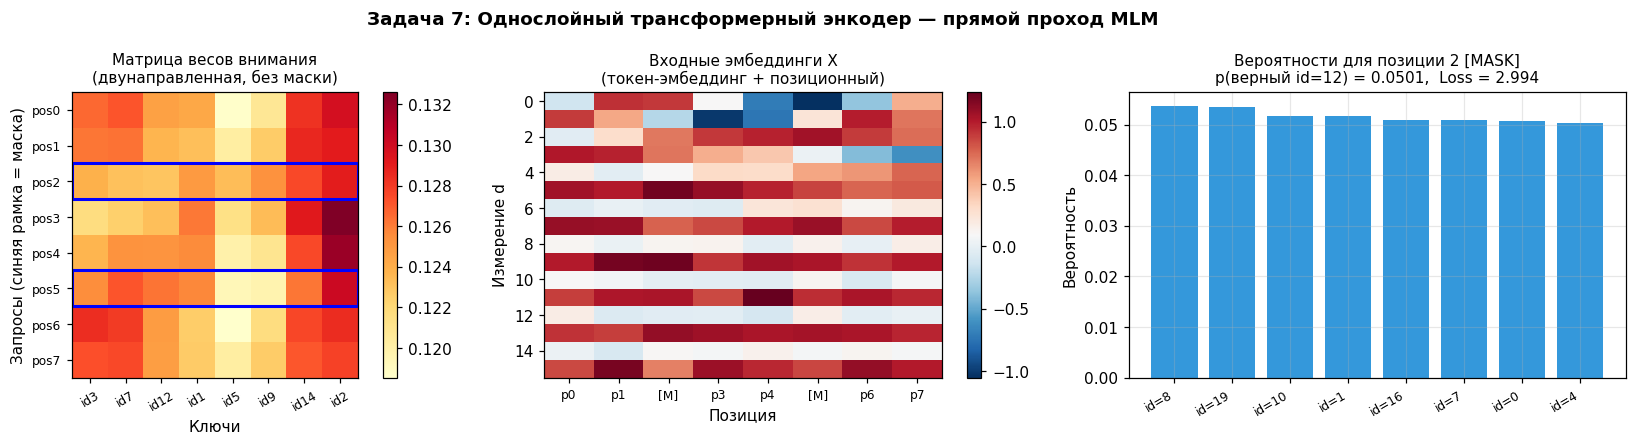

Результаты прямого прохода:
   Позиция   Верный ID     P(верный)      Loss
  --------------------------------------------
         2          12        0.0501    2.9937
         5           9        0.0484    3.0282

  MLM loss (по 2 маск. позициям): 3.0110
  Loss по всем 8 позициям (гипот.):          3.0091

Пояснение: у нетренированной модели вероятности почти равномерны (~1/V),
поэтому loss близок к log(V) = log(20) = 2.996.
После обучения p(верный) должна стремиться к 1, а loss — к 0.


In [ ]:
np.random.seed(2024)

# Гиперпараметры мини-BERT
V_small = 20   # размер словаря
N_seq   = 8    # длина последовательности
d       = 16   # размерность эмбеддингов
d_k     = 8    # размерность ключей/запросов

# --- Инициализация весов ---
E  = np.random.randn(V_small, d) * 0.1          # матрица токен-эмбеддингов [V, d]
W_Q = np.random.randn(d, d_k) * 0.1
W_K = np.random.randn(d, d_k) * 0.1
W_V = np.random.randn(d, d_k) * 0.1
W_O = np.random.randn(d_k, d) * 0.1             # проекция выхода обратно в d

# Синусоидальные позиционные эмбеддинги (формула Vaswani et al.)
P_pos = np.zeros((N_seq, d))
for pos in range(N_seq):
    for i in range(0, d, 2):
        P_pos[pos, i]     = np.sin(pos / (10000 ** (i / d)))
        if i + 1 < d:
            P_pos[pos, i+1] = np.cos(pos / (10000 ** (i / d)))

# --- Входная последовательность и маскирование ---
token_ids    = np.array([3, 7, 12, 1, 5, 9, 14, 2])
mask_positions = np.array([2, 5])   # маскируем позиции 2 и 5

# Шаг 1: Входные эмбеддинги = токен-эмбеддинги + позиционные
X = E[token_ids] + P_pos    # [N, d]

# Шаг 2: Self-Attention (двунаправленный — без маски)
Q     = X @ W_Q             # [N, d_k]
K     = X @ W_K             # [N, d_k]
V_mat = X @ W_V             # [N, d_k]

scores      = (Q @ K.T) / np.sqrt(d_k)    # [N, N] — нет маски!
attn_w      = softmax(scores)              # [N, N]
Z           = attn_w @ V_mat              # [N, d_k]
H           = Z @ W_O                     # [N, d]  — выходные векторы

# Шаг 3: Unembedding (weight tying: используем ту же матрицу E)
logits = H @ E.T            # [N, V]
probs  = softmax(logits)    # [N, V]

# Шаг 4: Loss только по замаскированным
losses_per_pos = []
for pos in mask_positions:
    true_id  = token_ids[pos]
    loss_pos = -np.log(probs[pos, true_id] + 1e-12)
    losses_per_pos.append((pos, true_id, probs[pos, true_id], loss_pos))
mlm_loss = np.mean([l for _, _, _, l in losses_per_pos])
full_loss = np.mean([-np.log(probs[i, token_ids[i]] + 1e-12) for i in range(N_seq)])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Задача 7: Однослойный трансформерный энкодер — прямой проход MLM",
             fontsize=12, fontweight='bold')

# Матрица внимания
im0 = axes[0].imshow(attn_w, cmap='YlOrRd')
axes[0].set_title("Матрица весов внимания\n(двунаправленная, без маски)", fontsize=10)
axes[0].set_xticks(range(N_seq))
axes[0].set_yticks(range(N_seq))
axes[0].set_xticklabels([f"id{t}" for t in token_ids], rotation=30, fontsize=8)
axes[0].set_yticklabels([f"pos{i}" for i in range(N_seq)], fontsize=8)
for pos in mask_positions:
    axes[0].add_patch(plt.Rectangle((-0.5, pos-0.5), N_seq, 1,
                                     fill=False, edgecolor='blue', linewidth=2))
plt.colorbar(im0, ax=axes[0])
axes[0].set_xlabel("Ключи")
axes[0].set_ylabel("Запросы (синяя рамка = маска)")

# Входные эмбеддинги
im1 = axes[1].imshow(X.T, cmap='RdBu_r', aspect='auto')
axes[1].set_title("Входные эмбеддинги X\n(токен-эмбеддинг + позиционный)", fontsize=10)
axes[1].set_xlabel("Позиция")
axes[1].set_ylabel("Измерение d")
axes[1].set_xticks(range(N_seq))
axes[1].set_xticklabels([f"[M]" if i in mask_positions else f"p{i}" for i in range(N_seq)],
                         fontsize=8)
plt.colorbar(im1, ax=axes[1])

# Предсказанные вероятности для первой замаскированной позиции
pos0, true_id0, prob0, loss0 = losses_per_pos[0]
top8 = np.argsort(probs[pos0])[::-1][:8]
bar_colors = ['#e74c3c' if t == true_id0 else '#3498db' for t in top8]
axes[2].bar(range(8), probs[pos0][top8], color=bar_colors)
axes[2].set_xticks(range(8))
axes[2].set_xticklabels([f"id={t}{' (верный)' if t==true_id0 else ''}" for t in top8],
                          rotation=30, ha='right', fontsize=8)
axes[2].set_title(f"Вероятности для позиции {pos0} [MASK]\n"
                  f"p(верный id={true_id0}) = {prob0:.4f},  Loss = {loss0:.3f}", fontsize=10)
axes[2].set_ylabel("Вероятность")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Результаты прямого прохода:")
print(f"  {'Позиция':>8}  {'Верный ID':>10}  {'P(верный)':>12}  {'Loss':>8}")
print("  " + "-" * 44)
for pos, true_id, prob, loss in losses_per_pos:
    print(f"  {pos:>8}  {true_id:>10}  {prob:>12.4f}  {loss:>8.4f}")
print(f"\n  MLM loss (по {len(mask_positions)} маск. позициям): {mlm_loss:.4f}")
print(f"  Loss по всем {N_seq} позициям (гипот.):          {full_loss:.4f}")
print("\nПояснение: у нетренированной модели вероятности почти равномерны (~1/V),")
print(f"поэтому loss близок к log(V) = log({V_small}) = {np.log(V_small):.3f}.")
print("После обучения p(верный) должна стремиться к 1, а loss — к 0.")

---

## Задача 8 (Сложная): MLM vs ELECTRA — сравнительная эффективность парадигм предобучения

### Постановка

ELECTRA (Clark et al., 2020) решает проблему неэффективности MLM через схему «генератор-дискриминатор». Нужно:

1. Симулировать работу генератора: замена замаскированных токенов на правдоподобные.
2. Показать, что дискриминатор ELECTRA обучается на $100\%$ позиций.
3. Сравнить кривые накопленных обучающих сигналов для MLM и ELECTRA.
4. Проанализировать, почему задача дискриминатора сложнее, чем кажется.

### Пояснение

**Схема ELECTRA:**

1. **Генератор** (маленькая MLM-модель) заменяет $15\%$ токенов на правдоподобные: в отличие от `[MASK]`, он подставляет реальные токены из словаря, выбирая их по выходным вероятностям. Например, для «Я пил горячий ___» генератор может поставить «кофе» вместо правильного «чай».

2. **Дискриминатор** (большая модель) смотрит на получившуюся последовательность и для **каждого** токена предсказывает: это оригинальный токен или заменённый? Это бинарная задача на каждой позиции.

Почему это лучше? Дискриминатор получает обучающий сигнал от **всех** $N$ токенов, а не от $15\%$. При тех же вычислительных затратах это даёт в $\approx 6.7$ раза больше обучающих сигналов.

**Чем сложна задача дискриминатора?** Когда генератор хорошо обучен, он подставляет семантически правдоподобные слова. Дискриминатор должен отличить «горячий кофе» (замена) от «горячий чай» (оригинал) — и то, и другое грамматически и семантически корректно. Это требует глубокого понимания контекста.

### Что нужно заметить

На графике покрытия токенов ELECTRA всегда держится на $100\%$ (все токены дают градиент), тогда как MLM — на $15\%$. Накопленные сигналы за 200 шагов расходятся в $1/0.15 \approx 6.7$ раза. При этом задача дискриминатора проще (бинарная, а не $V$-классовая), что частично компенсирует преимущество.

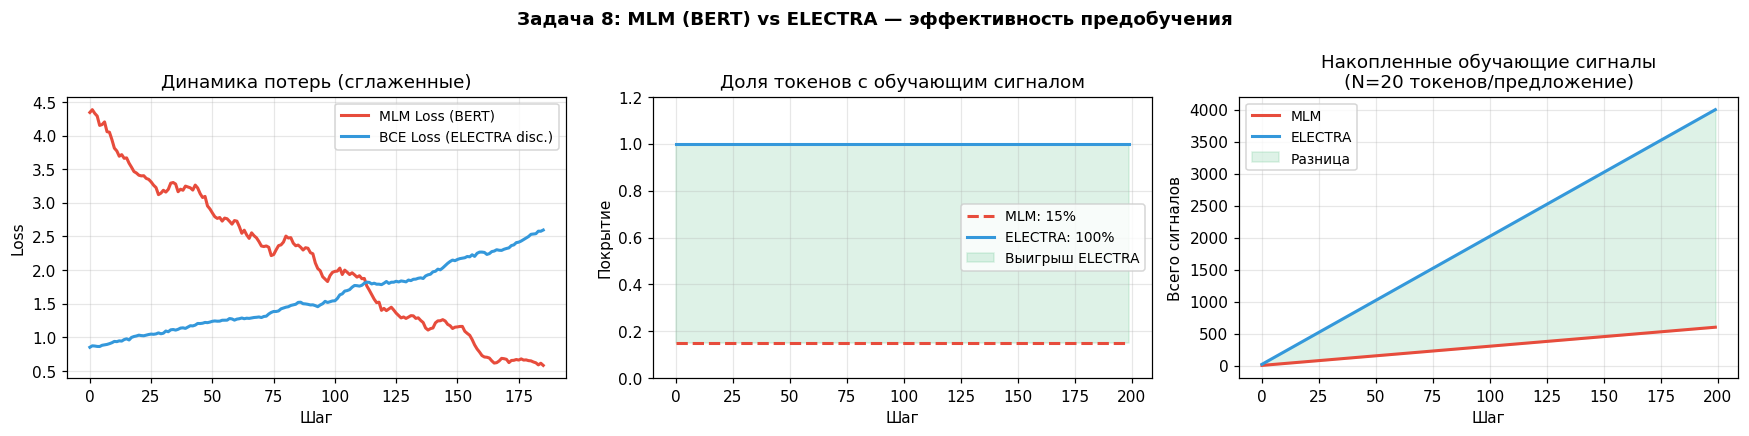

Итоговое сравнение за 200 шагов:
  MLM накопил обучающих сигналов:     600
  ELECTRA накопил:                    4000
  Отношение ELECTRA / MLM:            6.7x

Однако задачи разные по сложности:
  MLM предсказывает конкретный токен из V вариантов — сложная классификация.
  ELECTRA предсказывает 'оригинал или нет' — бинарная классификация.
  Но при сильном генераторе замены правдоподобны, и бинарная задача тоже сложна.


In [ ]:
np.random.seed(99)

V_E = 50
N_E = 20
STEPS_E = 200

def generator_replace(tokens, quality_gen):
    """
    Имитация генератора ELECTRA.
    quality_gen (0..1) — насколько хорош генератор:
      0 = случайные замены, 1 = всегда близкий к оригиналу токен.
    Возвращает: испорченные токены, бинарные метки (0=ориг, 1=заменён).
    """
    n_mask = max(1, int(0.15 * len(tokens)))
    mask_pos = np.random.choice(len(tokens), n_mask, replace=False)
    corrupted = tokens.copy()
    labels = np.zeros(len(tokens), dtype=int)

    for pos in mask_pos:
        orig = tokens[pos]
        if np.random.random() < (1 - quality_gen):
            # Слабый генератор: случайная замена
            replacement = np.random.randint(0, V_E)
        else:
            # Сильный генератор: близкий токен (±2 в ID — имитация семантической близости)
            candidates = [c for c in range(max(0, orig-2), min(V_E, orig+3)) if c != orig]
            replacement = np.random.choice(candidates) if candidates else orig
        corrupted[pos] = replacement
        labels[pos] = int(replacement != orig)

    return corrupted, labels

mlm_losses, electra_losses, electra_coverage = [], [], []

for step in range(STEPS_E):
    quality = step / STEPS_E
    tokens = np.random.randint(0, V_E, N_E)

    # MLM: loss по 15% токенов
    n_m = max(1, int(0.15 * N_E))
    m_pos = np.random.choice(N_E, n_m, replace=False)
    mlm_loss_val = np.mean([
        -np.log(softmax(np.random.randn(V_E) + np.eye(V_E)[tokens[p]] * quality * 5)[tokens[p]] + 1e-12)
        for p in m_pos
    ])
    mlm_losses.append(mlm_loss_val)

    # ELECTRA: бинарный CE по ВСЕМ токенам
    corrupted, labels = generator_replace(tokens, quality_gen=quality * 0.7)
    disc_logits = np.random.randn(N_E) + quality * 2.5 * (1 - 2 * labels)
    disc_probs = 1 / (1 + np.exp(-disc_logits))
    bce = -np.mean(
        labels * np.log(disc_probs + 1e-12) +
        (1 - labels) * np.log(1 - disc_probs + 1e-12)
    )
    electra_losses.append(bce)
    electra_coverage.append(1.0)

def smooth(arr, w=15):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Задача 8: MLM (BERT) vs ELECTRA — эффективность предобучения",
             fontsize=12, fontweight='bold')

# 1. Кривые потерь
w_s = 15
axes[0].plot(smooth(mlm_losses, w_s),     color='#e74c3c', linewidth=2, label='MLM Loss (BERT)')
axes[0].plot(smooth(electra_losses, w_s), color='#3498db', linewidth=2, label='BCE Loss (ELECTRA disc.)')
axes[0].set_title("Динамика потерь (сглаженные)")
axes[0].set_xlabel("Шаг")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. Покрытие
steps_arr = np.arange(STEPS_E)
axes[1].plot(steps_arr, [0.15]*STEPS_E, color='#e74c3c', linewidth=2, linestyle='--', label='MLM: 15%')
axes[1].plot(steps_arr, electra_coverage, color='#3498db', linewidth=2, label='ELECTRA: 100%')
axes[1].fill_between(steps_arr, 0.15, 1.0, alpha=0.15, color='#27ae60', label='Выигрыш ELECTRA')
axes[1].set_ylim(0, 1.2)
axes[1].set_title("Доля токенов с обучающим сигналом")
axes[1].set_xlabel("Шаг")
axes[1].set_ylabel("Покрытие")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Накопленные сигналы
mlm_cum     = np.cumsum([N_E * 0.15] * STEPS_E)
electra_cum = np.cumsum([N_E * 1.0]  * STEPS_E)
axes[2].plot(steps_arr, mlm_cum,     color='#e74c3c', linewidth=2, label='MLM')
axes[2].plot(steps_arr, electra_cum, color='#3498db', linewidth=2, label='ELECTRA')
axes[2].fill_between(steps_arr, mlm_cum, electra_cum,
                     alpha=0.15, color='#27ae60', label='Разница')
axes[2].set_title(f"Накопленные обучающие сигналы\n(N={N_E} токенов/предложение)")
axes[2].set_xlabel("Шаг")
axes[2].set_ylabel("Всего сигналов")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Итоговое сравнение за 200 шагов:")
print(f"  MLM накопил обучающих сигналов:     {int(mlm_cum[-1])}")
print(f"  ELECTRA накопил:                    {int(electra_cum[-1])}")
print(f"  Отношение ELECTRA / MLM:            {electra_cum[-1]/mlm_cum[-1]:.1f}x")
print("\nОднако задачи разные по сложности:")
print("  MLM предсказывает конкретный токен из V вариантов — сложная классификация.")
print("  ELECTRA предсказывает 'оригинал или нет' — бинарная классификация.")
print("  Но при сильном генераторе замены правдоподобны, и бинарная задача тоже сложна.")

---

## Задачи для самостоятельного решения

---

### Задача С1: Влияние гиперпараметров маскирования на MLM-loss

**Контекст.** В BERT выбрано маскировать $15\%$ токенов с правилом $80/10/10$. Эти числа были подобраны эмпирически. Какой был бы эффект, если выбрать другие значения?

**Задание.** Реализуйте функцию `simulate_mlm(mask_ratio, p_mask, n_steps=50)`, симулирующую MLM-обучение при заданных параметрах (оставшаяся вероятность $1 - p_{\text{mask}}$ делится поровну между случайным токеном и без изменений). Проведите grid search по `mask_ratio in {0.05, 0.10, 0.15, 0.20, 0.25, 0.30}` и `p_mask in {0.60, 0.70, 0.80, 0.90, 1.00}`. Для каждой комбинации запишите финальный loss. Постройте тепловую карту и ответьте: при каких параметрах loss минимален? Совпадают ли они с настройками BERT?

**Подсказка.** Вариант `p_keep` (без изменений) не даёт явного обучающего сигнала для выбора правильного токена — модель и так его «видит». Вариант `p_random` создаёт сигнал исправления ошибки, что может быть полезно или вредно в зависимости от доли. Попробуйте объяснить наблюдаемую картину.

---

### Задача С2: Синусоидальные позиционные эмбеддинги и их свойства

**Контекст.** BERT использует обучаемые позиционные эмбеддинги. Исходный трансформер (Vaswani et al.) применяет фиксированные синусоидальные функции:
$$PE(\text{pos}, 2i) = \sin\!\left(\frac{\text{pos}}{10000^{2i/d}}\right), \quad PE(\text{pos}, 2i+1) = \cos\!\left(\frac{\text{pos}}{10000^{2i/d}}\right)$$

**Задание.** Реализуйте вычисление матрицы $PE \in \mathbb{R}^{N \times d}$ для $N=64, d=128$. Визуализируйте её как тепловую карту. Вычислите матрицу косинусных сходств между позициями и постройте её. Объясните: почему близкие позиции имеют высокое сходство? Какую роль играют «частоты» — высокочастотные (мелкие изменения) и низкочастотные (крупные изменения) измерения? Сравните с матрицей случайных обучаемых эмбеддингов (случайная инициализация).

---

### Задача С3: Анализ NSP — является ли задача слишком простой?

**Контекст.** Одна из главных критик NSP состоит в том, что задача решается с помощью поверхностных лексических признаков, без понимания связности текста.

**Задание.** Создайте корпус из 10 тематических блоков по 5–6 предложений каждый (например, блок про науку, блок про природу и т.д.). Сформируйте 40 NSP-пар: 20 позитивных (смежные предложения из одного блока) и 20 негативных (случайные пары из разных блоков). Реализуйте наивный лексический классификатор: пара считается позитивной, если число общих уникальных слов превышает порог $\theta$. Оцените его accuracy при разных $\theta$ и постройте ROC-кривую (используйте `sklearn.metrics`). Если AUC значительно выше $0.5$, это означает, что лексические признаки уже решают задачу — модели BERT не нужно ничему учиться.

---

